In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [26]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

In [2]:
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import AdaBoostClassifier

In [31]:
from sklearn.metrics import accuracy_score, classification_report

In [3]:
#import pandas as pd
Input_data=pd.read_csv("values.csv")
output_data=pd.read_csv("labels.csv")

In [4]:
df = pd.merge(Input_data, output_data, on="patient_id")

In [5]:
df.head()

,patient_id,slope_of_peak_exercise_st_segment,thal,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina,heart_disease_present
0,0z64un,1,normal,128,2,0,0,2,308,0.0,1,45,170,0,0
1,ryoo3j,2,normal,110,3,0,0,0,214,1.6,0,54,158,0,0
2,yt1s1x,1,normal,125,4,3,0,2,304,0.0,1,77,162,1,1
3,l2xjde,1,reversible_defect,152,4,0,0,0,223,0.0,1,40,181,0,1
4,oyt4ek,3,reversible_defect,178,1,0,0,2,270,4.2,1,59,145,0,0


In [6]:
df.tail()

,patient_id,slope_of_peak_exercise_st_segment,thal,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina,heart_disease_present
175,5qfar3,2,reversible_defect,125,4,2,1,0,254,0.2,1,67,163,0,1
176,2s2b1f,2,normal,180,4,0,0,1,327,3.4,0,55,117,1,1
177,nsd00i,2,reversible_defect,125,3,0,0,0,309,1.8,1,64,131,1,1
178,0xw93k,1,normal,124,3,2,1,0,255,0.0,1,48,175,0,0
179,2nx10r,1,normal,160,3,1,0,0,201,0.0,0,54,163,0,0


In [7]:
df.shape

(180, 15)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 15 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   patient_id                            180 non-null    object 
 1   slope_of_peak_exercise_st_segment     180 non-null    int64  
 2   thal                                  180 non-null    object 
 3   resting_blood_pressure                180 non-null    int64  
 4   chest_pain_type                       180 non-null    int64  
 5   num_major_vessels                     180 non-null    int64  
 6   fasting_blood_sugar_gt_120_mg_per_dl  180 non-null    int64  
 7   resting_ekg_results                   180 non-null    int64  
 8   serum_cholesterol_mg_per_dl           180 non-null    int64  
 9   oldpeak_eq_st_depression              180 non-null    float64
 10  sex                                   180 non-null    int64  
 11  age                

In [9]:
df.describe()

,slope_of_peak_exercise_st_segment,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina,heart_disease_present
count,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000
mean,1.550000,131.311111,3.155556,0.694444,0.161111,1.050000,249.211111,1.010000,0.688889,54.811111,149.483333,0.316667,0.444444
std,0.618838,17.010443,0.938454,0.969347,0.368659,0.998742,52.717969,1.121357,0.464239,9.334737,22.063513,0.466474,0.498290
min,1.000000,94.000000,1.000000,0.000000,0.000000,0.000000,126.000000,0.000000,0.000000,29.000000,96.000000,0.000000,0.000000
25%,1.000000,120.000000,3.000000,0.000000,0.000000,0.000000,213.750000,0.000000,0.000000,48.000000,132.000000,0.000000,0.000000
50%,1.000000,130.000000,3.000000,0.000000,0.000000,2.000000,245.500000,0.800000,1.000000,55.000000,152.000000,0.000000,0.000000
75%,2.000000,140.000000,4.000000,1.000000,0.000000,2.000000,281.250000,1.600000,1.000000,62.000000,166.250000,1.000000,1.000000
max,3.000000,180.000000,4.000000,3.000000,1.000000,2.000000,564.000000,6.200000,1.000000,77.000000,202.000000,1.000000,1.000000


In [10]:
df.isnull().sum()

patient_id                              0
slope_of_peak_exercise_st_segment       0
thal                                    0
resting_blood_pressure                  0
chest_pain_type                         0
num_major_vessels                       0
fasting_blood_sugar_gt_120_mg_per_dl    0
resting_ekg_results                     0
serum_cholesterol_mg_per_dl             0
oldpeak_eq_st_depression                0
sex                                     0
age                                     0
max_heart_rate_achieved                 0
exercise_induced_angina                 0
heart_disease_present                   0
dtype: int64

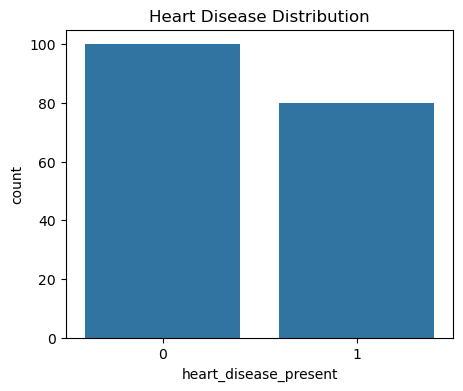

In [11]:
plt.figure(figsize=(5,4))
sns.countplot(x=df["heart_disease_present"])
plt.title("Heart Disease Distribution")
plt.show()

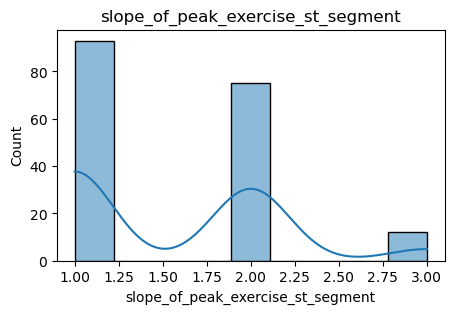

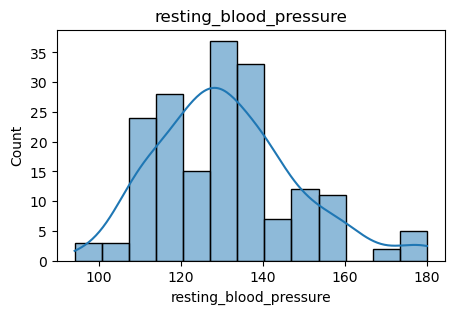

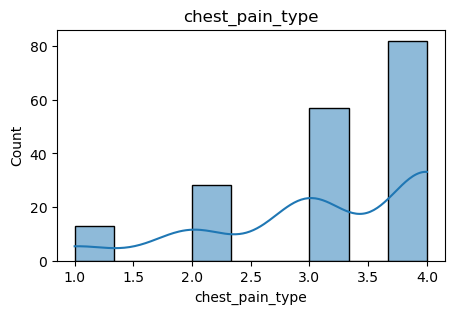

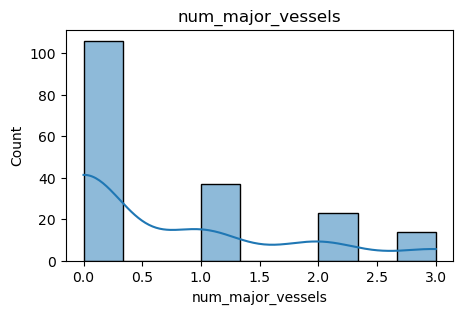

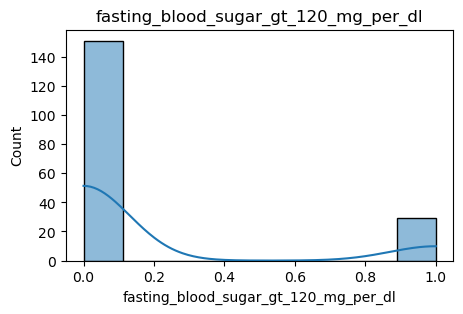

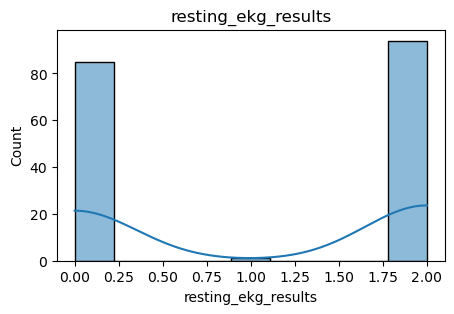

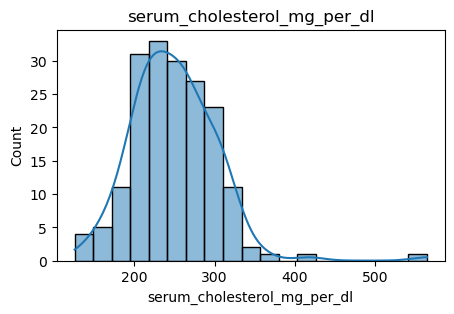

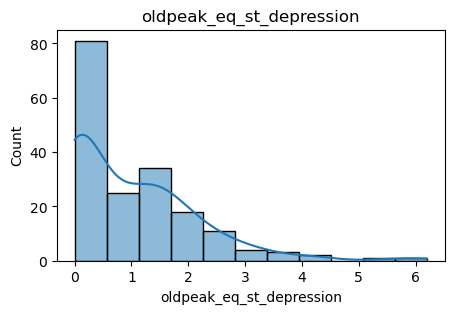

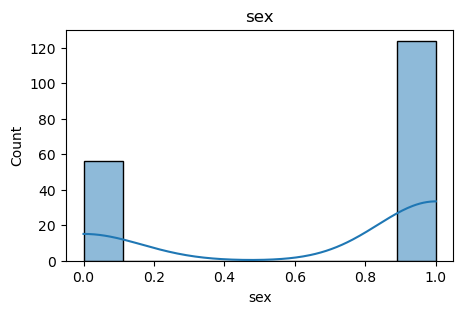

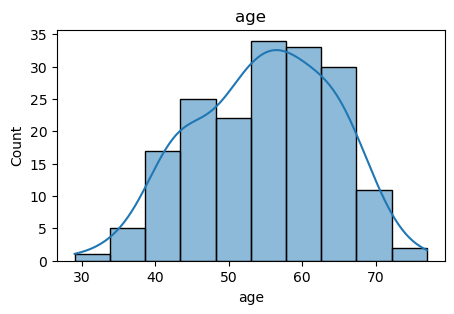

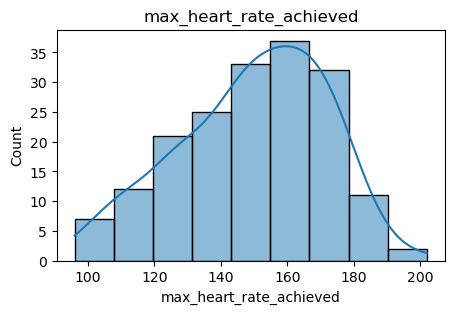

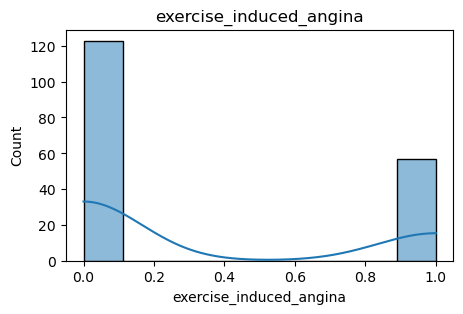

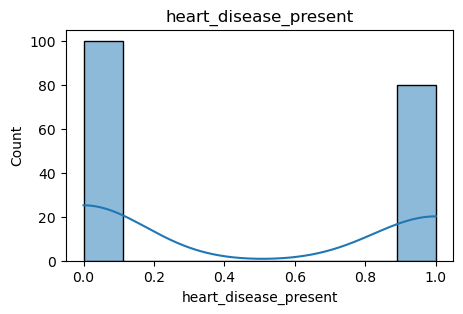

In [12]:
numeric_cols = df.select_dtypes(include=["int64","float64"]).columns

for col in numeric_cols:
    
    plt.figure(figsize=(5,3))
    sns.histplot(df[col], kde=True)
    plt.title(col)
    plt.show()

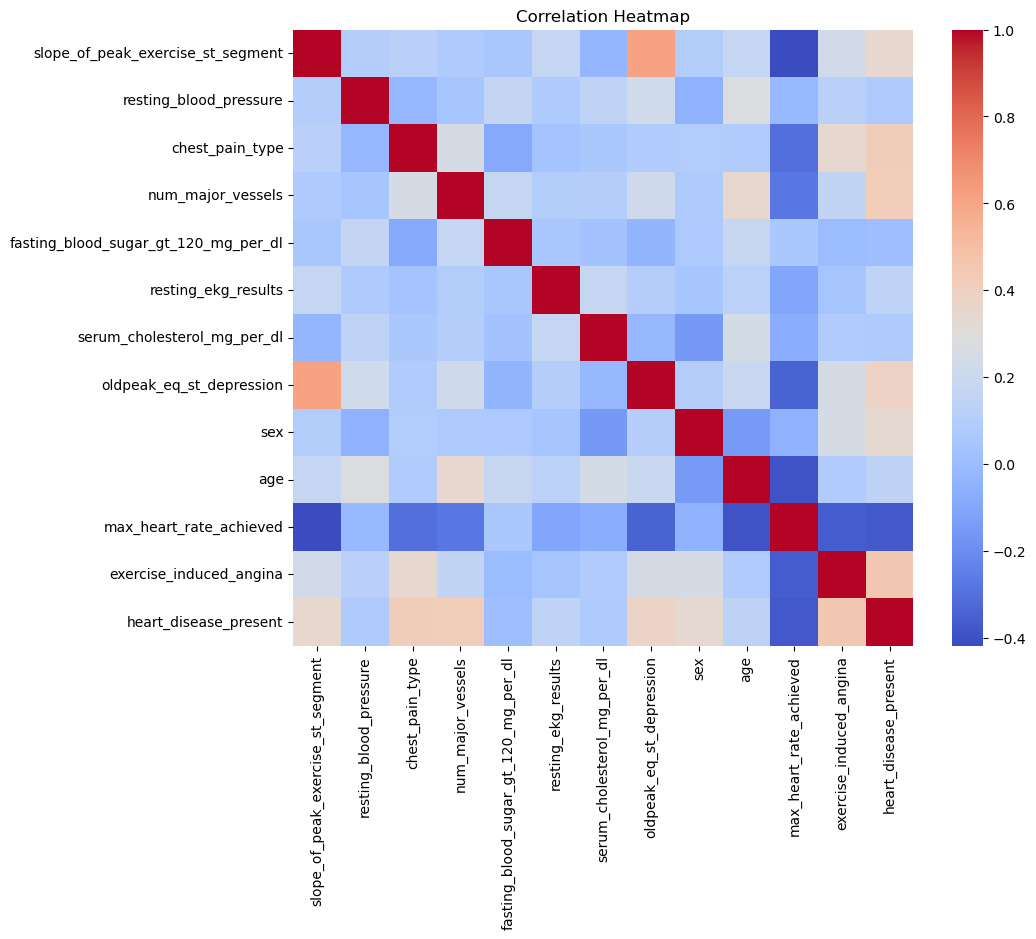

In [15]:
numeric_df = df.select_dtypes(include=['int64','float64'])
corr = numeric_df.corr()
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(10,8))
sns.heatmap(corr, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [16]:
corr["heart_disease_present"].sort_values(ascending=False)

heart_disease_present                   1.000000
exercise_induced_angina                 0.448647
num_major_vessels                       0.421519
chest_pain_type                         0.412829
oldpeak_eq_st_depression                0.382930
slope_of_peak_exercise_st_segment       0.344224
sex                                     0.335421
resting_ekg_results                     0.145933
age                                     0.138255
serum_cholesterol_mg_per_dl             0.079775
resting_blood_pressure                  0.078506
fasting_blood_sugar_gt_120_mg_per_dl    0.003379
max_heart_rate_achieved                -0.375352
Name: heart_disease_present, dtype: float64

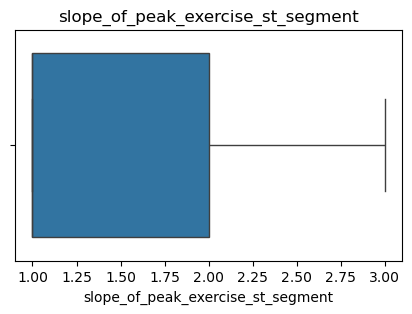

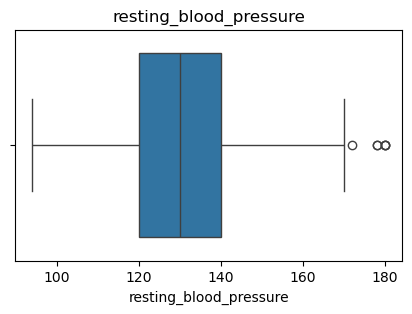

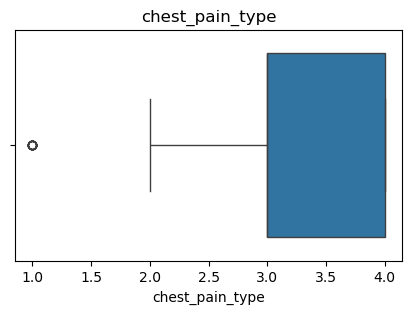

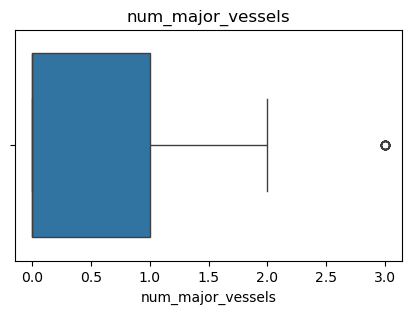

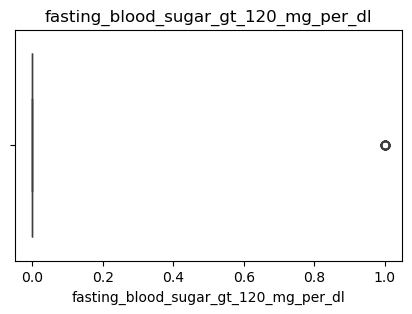

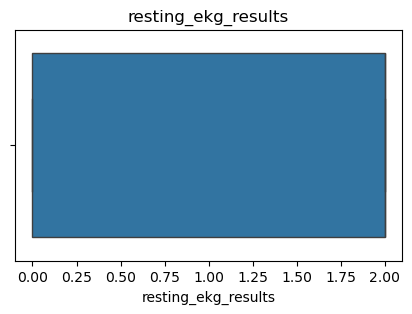

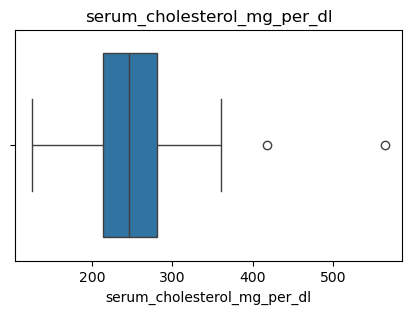

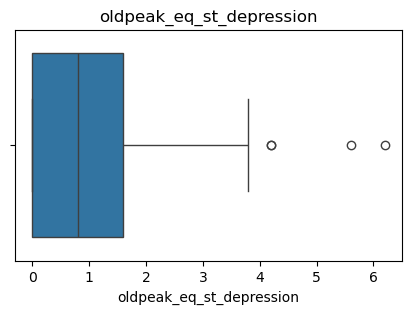

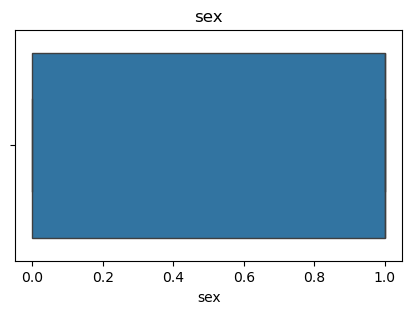

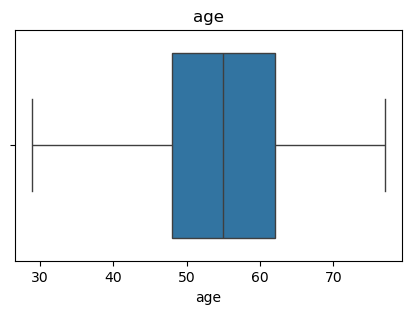

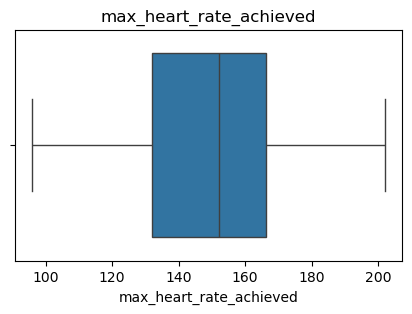

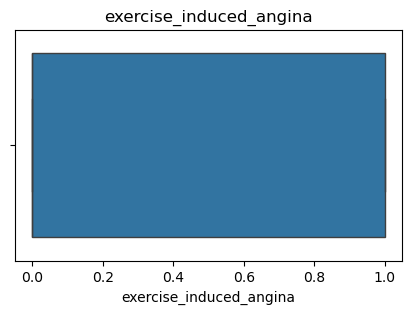

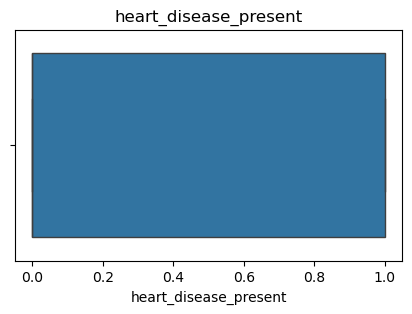

In [18]:
for col in numeric_cols:
    plt.figure(figsize=(5,3))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

In [20]:
df = df.drop("patient_id", axis=1)

In [21]:
x = df.drop("heart_disease_present", axis=1)
y = df["heart_disease_present"]

In [23]:
num_cols = x.select_dtypes(include=["int64","float64"]).columns
cat_cols = x.select_dtypes(include=["object"]).columns

In [27]:
num_pipeline = Pipeline([
    
    ("imputer", SimpleImputer(strategy="median")),
    
    ("scaler", StandardScaler())
])
cat_pipeline = Pipeline([
    
    ("imputer", SimpleImputer(strategy="most_frequent")),
    
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])
preprocessor = ColumnTransformer([
    
    ("num", num_pipeline, num_cols),
    
    ("cat", cat_pipeline, cat_cols)
])

In [28]:
x_train, x_test, y_train, y_test = train_test_split(
    
    x,y,
    
    test_size=0.2,
    
    random_state=42
)

In [32]:
models = {

"Logistic Regression": LogisticRegression(max_iter=1000),

"Decision Tree": DecisionTreeClassifier(),

"KNN": KNeighborsClassifier(),

"SVM": SVC(),

"Random Forest": RandomForestClassifier(),

"Gradient Boosting": GradientBoostingClassifier(),

"Extra Trees": ExtraTreesClassifier(),

"AdaBoost": AdaBoostClassifier(),

"Naive Bayes": GaussianNB()
}

results = []
for name, model in models.items():
    
    pipe = Pipeline([
        
        ("preprocessor", preprocessor),
        
        ("model", model)
    ])
    
    pipe.fit(x_train, y_train)
    
    preds = pipe.predict(x_test)
    
    acc = accuracy_score(y_test, preds)
    
    results.append([name, acc])

results = pd.DataFrame(results, columns=["Model","Accuracy"])

results.sort_values(by="Accuracy", ascending=False)

,Model,Accuracy
2,KNN,0.888889
8,Naive Bayes,0.861111
4,Random Forest,0.861111
6,Extra Trees,0.861111
0,Logistic Regression,0.833333
7,AdaBoost,0.833333
3,SVM,0.833333
1,Decision Tree,0.777778
5,Gradient Boosting,0.750000


In [40]:
pipeline = Pipeline([
    
    ("preprocessor", preprocessor),
    
    ("model", ExtraTreesClassifier())
])
param_grid = {

"model__n_estimators":[100,200,300],

"model__max_depth":[None,5,10],

"model__min_samples_split":[2,5]
}
grid = GridSearchCV(
    
    pipeline,
    
    param_grid,
    
    cv=5,
    
    scoring="accuracy"
)
grid.fit(x_train, y_train)
best_model = grid.best_estimator_
print("Best Parameters:", grid.best_params_)

Best Parameters: {'model__max_depth': None, 'model__min_samples_split': 5, 'model__n_estimators': 200}


In [35]:
preds = best_model.predict(x_test)
print("Accuracy:", accuracy_score(y_test, preds))
print(classification_report(y_test, preds))

Accuracy: 0.8611111111111112
              precision    recall  f1-score   support

           0       0.79      0.94      0.86        16
           1       0.94      0.80      0.86        20

    accuracy                           0.86        36
   macro avg       0.87      0.87      0.86        36
weighted avg       0.87      0.86      0.86        36



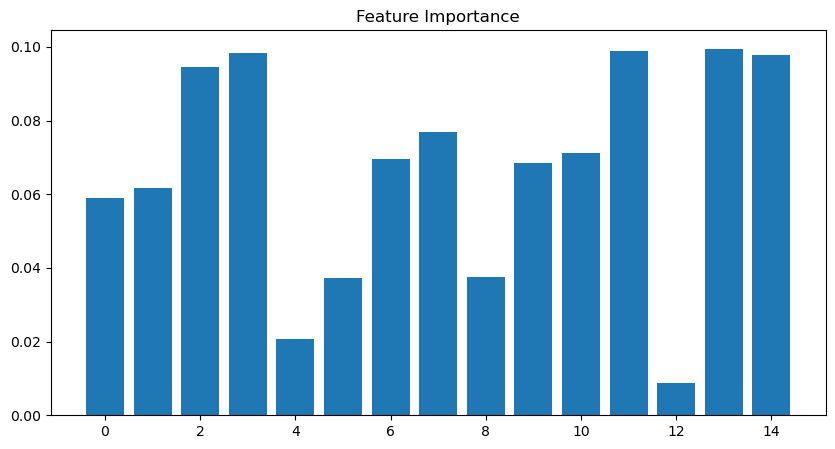

In [36]:
model = best_model.named_steps["model"]
importance = model.feature_importances_
plt.figure(figsize=(10,5))
plt.bar(range(len(importance)), importance)
plt.title("Feature Importance")
plt.show()